In [1]:
import sys
sys.path.insert(0, '..')

import pickle
import pandas as pd
from src.indexing.embeddings import (
    load_embedding_model, embed_chunks, embed_query, get_embedding_dim
)
from src.indexing.vector_store import (
    load_vector_store, reset_vector_store, index_chunks, query_collection
)

with open('../data/processed/chunks.pkl', 'rb') as f:
    chunks = pickle.load(f)

print(f'Loaded {len(chunks)} chunks from {len({c["method"] for c in chunks})} papers')

/Users/madhumithakatam/Documents/Projects/SR_RAG/sr-rag/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 695 chunks from 10 papers


In [2]:
model = load_embedding_model()
dim = get_embedding_dim()
print(f'Model loaded. Embedding dimension: {dim}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 25289.08it/s]


Model loaded. Embedding dimension: 384


/Users/madhumithakatam/Documents/Projects/SR_RAG/sr-rag/notebooks/../src/indexing/embeddings.py:118: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  return model.get_sentence_embedding_dimension()


In [3]:
chunks = embed_chunks(chunks, show_progress=True)
print(f'Done. Sample embedding (first 8 values): {chunks[0]["embedding"][:8]}')

Batches: 100%|██████████| 11/11 [00:03<00:00,  2.92it/s]

Done. Sample embedding (first 8 values): [-0.034371133893728256, -0.06637211889028549, 0.08806668967008591, 0.04277282580733299, -0.002751237479969859, 0.0044533140026032925, -0.06719032675027847, -0.03554964438080788]


In [4]:
import numpy as np

vectors = np.array([c['embedding'] for c in chunks])
print(f'Embedding matrix shape : {vectors.shape}')   # should be (n_chunks, 384)
print(f'Mean norm              : {np.linalg.norm(vectors, axis=1).mean():.4f}')  # should be ~1.0
print(f'Value range            : [{vectors.min():.4f}, {vectors.max():.4f}]')

Embedding matrix shape : (695, 384)
Mean norm              : 1.0000
Value range            : [-0.2203, 0.2063]


In [5]:
collection = reset_vector_store(
    persist_dir='../vector_store',
    collection_name='sr_papers',
)
index_chunks(collection, chunks)
print(f'\nCollection size: {collection.count()} chunks')


Collection size: 695 chunks


In [6]:
def show_results(query, top_k=3):
    qv = embed_query(query)
    results = query_collection(collection, qv, top_k=top_k)
    print(f'Query: "{query}"')
    print('-' * 60)
    for r in results:
        print(f"[{r['citation_index']}] {r['method']} | p{r['page_number']} | score={r['score']:.3f}")
        print(f"    {r['text'][:200]}...")
        print()

show_results('What loss function does SRGAN use?')

Query: "What loss function does SRGAN use?"
------------------------------------------------------------
[1] SRGAN / SRResNet | p7 | score=0.688
    Table 1: Performance of different loss functions for SR-
ResNet and the adversarial networks on Set5 and Set14
benchmark data. MOS score significantly higher (p < 0.05)
than with other losses in that ...

[2] SRGAN / SRResNet | p7 | score=0.637
    V GG/5.4 with φ5,4, a loss defined
on feature maps of higher level features from deeper
network layers with more potential to focus on the
content of the images [68, 65, 40]. We refer to this
network ...

[3] SRGAN / SRResNet | p7 | score=0.630
    that are, however, perceptually rather smooth and less
convincing than results achieved with a loss component
more sensitive to visual perception.
This is caused by
competition between the MSE-based c...



In [7]:
show_results('How does SwinIR use transformer attention?')

Query: "How does SwinIR use transformer attention?"
------------------------------------------------------------
[1] HAT | p13 | score=0.630
    SwinIR. 2) We enlarge SwinIR by increasing the width and
depth of SwinIR to achieve similar computations as HAT,
denoted as SwinIR-L1 and SwinIR-L2. HAT achieves the
best performance at the lowest com...

[2] HAT | p1 | score=0.612
    mechanism and utilize long-range information. Thus, we
employ the attribution analysis method LAM [15] to ex-
amine the involved range of utilized information for recon-
struction in SwinIR. Interesti...

[3] HAT | p1 | score=0.600
    intermediate features of SwinIR, as depicted in Fig. 3. It
demonstrates that the shift window mechanism cannot per-
fectly realize cross-window information interaction.
1
arXiv:2205.04437v3  [eess.IV]...



In [8]:
show_results('Which papers report PSNR on DIV2K?')

Query: "Which papers report PSNR on DIV2K?"
------------------------------------------------------------
[1] EDSR | p7 | score=0.410
    performance and blue indicates the second best. Note that DIV2K validation results are acquired from published demo
codes.
4.5. Benchmark Results
We provide the quantitative evaluation results of our ...

[2] ESRGAN | p21 | score=0.391
    dataset, increases the PSNR performance (see Tab. 2).
Table 2: Quantitative evaluation of state-of-the-art PSNR-oriented SR algo-
rithms: average PSNR/SSIM on Y channel. The best and second best resul...

[3] ESRGAN | p21 | score=0.366
    ESRGAN Supplementary File
21
0
200k
400k
600k
800k
1000k
Iteration
5
10
15
20
25
30
PSNR
MSRA init x0.1
residual scaling (x0.2)
MSRA init
(a)
0
200k
400k
600k
800k
1000k
Iteration
29.8
29.9
30.0
30.1
...



In [9]:
show_results('What is residual channel attention?')

Query: "What is residual channel attention?"
------------------------------------------------------------
[1] RCAN | p8 | score=0.585
    8
Yulun Zhang et al.
Channel attention
Conv
ReLU
Global 
pooling
Sigmoid 
function
Element-wise 
product
Element-wise 
sum
Fg,b-1
Fg,b
Xg,b
Fig. 4. Residual channel attention block (RCAB)
3.4
Residual...

[2] RCAN | p1 | score=0.581
    resentational ability of CNNs. To solve these problems, we propose the
very deep residual channel attention networks (RCAN). Specifically, we
propose a residual in residual (RIR) structure to form ver...

[3] RCAN | p2 | score=0.577
    structure, where the residual group (RG) serves as the basic module and long skip
connection (LSC) allows residual learning in a coarse level. In each RG module,
we stack several simplified residual b...



Average top-1 score : 0.640
Min top-1 score     : 0.505
Max top-1 score     : 0.774


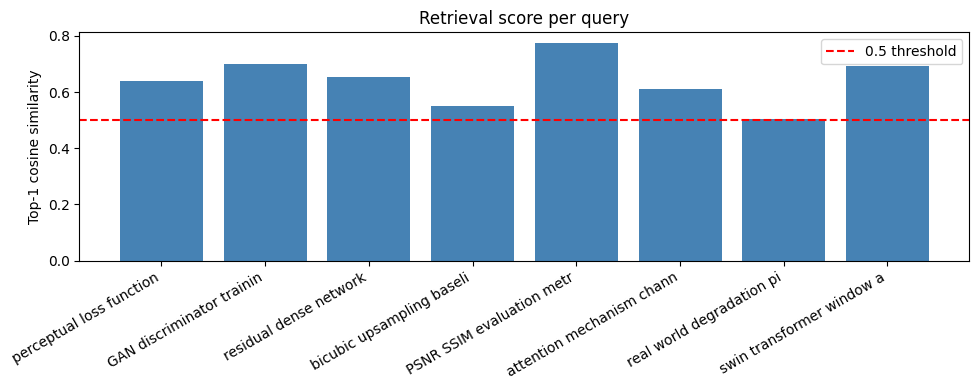

In [10]:
import matplotlib.pyplot as plt

test_queries = [
    'perceptual loss function',
    'GAN discriminator training',
    'residual dense network',
    'bicubic upsampling baseline',
    'PSNR SSIM evaluation metrics',
    'attention mechanism channel',
    'real world degradation pipeline',
    'swin transformer window attention',
]

all_top1 = []
for q in test_queries:
    qv = embed_query(q)
    res = query_collection(collection, qv, top_k=5)
    all_top1.append(res[0]['score'])

print(f'Average top-1 score : {sum(all_top1)/len(all_top1):.3f}')
print(f'Min top-1 score     : {min(all_top1):.3f}')
print(f'Max top-1 score     : {max(all_top1):.3f}')

plt.figure(figsize=(10, 4))
plt.bar(range(len(test_queries)), all_top1, color='steelblue')
plt.xticks(range(len(test_queries)), [q[:25] for q in test_queries], rotation=30, ha='right')
plt.ylabel('Top-1 cosine similarity')
plt.title('Retrieval score per query')
plt.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
plt.legend()
plt.tight_layout()
plt.show()